Using device: cuda
Training samples : 1,000  (members)
Test samples     : 1,000  (non-members)
Validation set   : 400  (held-out)
Dataset ready.


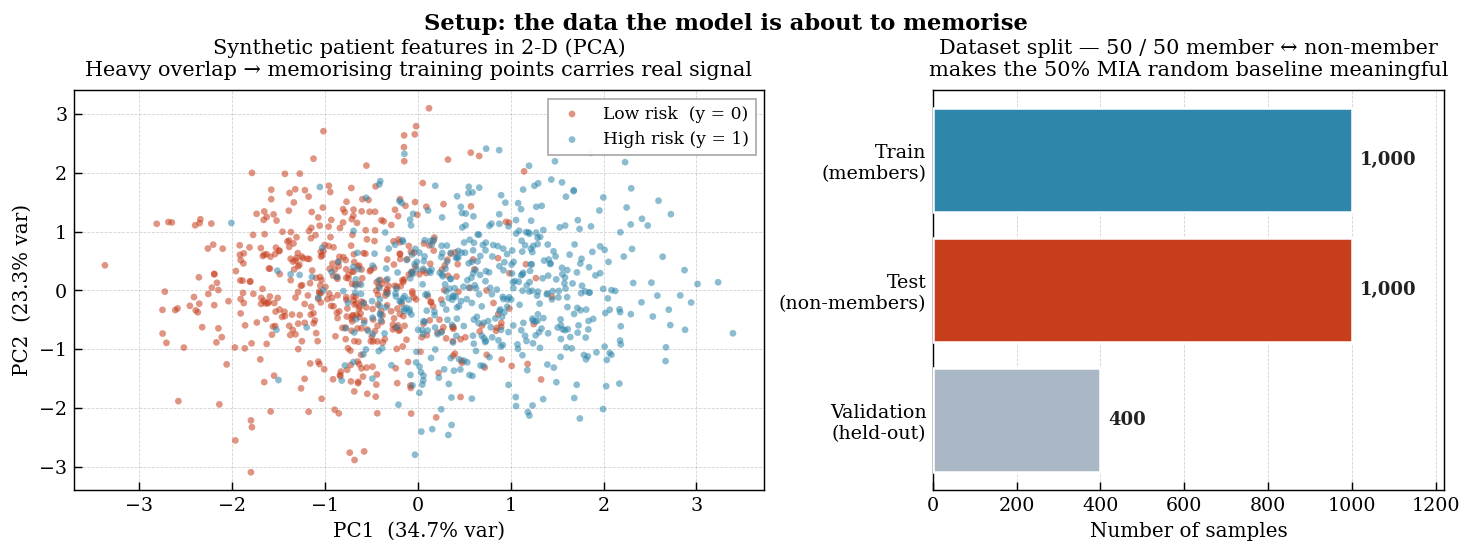

In [13]:
# Cell 1: Imports, synthetic patient data, and dataset visualisation
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

mpl.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['DejaVu Serif', 'Liberation Serif', 'Nimbus Roman'],
    'font.size':         10.5,
    'axes.titlesize':    11.5,
    'axes.labelsize':    11,
    'axes.linewidth':    0.8,
    'axes.edgecolor':    'black',
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  4.5,
    'ytick.major.size':  4.5,
    'figure.dpi':        130,
    'savefig.dpi':       300,
    'legend.frameon':    True,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  '#aaaaaa',
    'legend.fancybox':   False,
})

MEMBER_COLOR    = '#2E86AB'
NONMEMBER_COLOR = '#C73E1D'
OVERFIT_COLOR   = '#C73E1D'
REG_COLOR       = '#3FA796'
DP_COLOR        = '#7B3294'
GRID_COLOR      = '#999999'

def _grid(ax, axis='y'):
    if axis in ('x', 'both'):
        ax.xaxis.grid(True, linestyle='--', linewidth=0.45, alpha=0.45, color=GRID_COLOR)
    if axis in ('y', 'both'):
        ax.yaxis.grid(True, linestyle='--', linewidth=0.45, alpha=0.45, color=GRID_COLOR)
    ax.set_axisbelow(True)

# 4 features (Age, BP, Cholesterol, Glucose) drawn from two Gaussians.
# Means are kept small so the classes overlap -- without overlap the model
# would not need to memorise anything and there would be no MIA signal.
N      = 2000
N_FEAT = 4
RISK_MEAN     = np.array([ 0.4,  0.35,  0.3,  0.5], dtype=np.float32)
NORISK_MEAN   = -RISK_MEAN

X_risk   = (np.random.randn(N//2, N_FEAT) + RISK_MEAN).astype(np.float32)
y_risk   = np.ones(N//2, dtype=np.float32)
X_norisk = (np.random.randn(N//2, N_FEAT) + NORISK_MEAN).astype(np.float32)
y_norisk = np.zeros(N//2, dtype=np.float32)

X = np.vstack([X_risk, X_norisk])
y = np.concatenate([y_risk, y_norisk])

# 50/50 split keeps the random-guess baseline at exactly 50%.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

# Held-out validation set, used only by the early-stopping defense.
N_VAL = 400
X_val_risk   = (np.random.randn(N_VAL//2, N_FEAT) + RISK_MEAN).astype(np.float32)
X_val_norisk = (np.random.randn(N_VAL//2, N_FEAT) + NORISK_MEAN).astype(np.float32)
X_val = np.vstack([X_val_risk, X_val_norisk])
y_val = np.concatenate([np.ones(N_VAL//2, dtype=np.float32),
                        np.zeros(N_VAL//2, dtype=np.float32)])

print(f'Training samples : {len(X_train):,}  (members)')
print(f'Test samples     : {len(X_test):,}  (non-members)')
print(f'Validation set   : {len(X_val):,}  (held-out)')

# Scaler fit on training data only.
scaler  = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)
X_val   = scaler.transform(X_val)

X_tr  = torch.tensor(X_train, dtype=torch.float32)
y_tr  = torch.tensor(y_train, dtype=torch.float32)
X_te  = torch.tensor(X_test,  dtype=torch.float32)
y_te  = torch.tensor(y_test,  dtype=torch.float32)
X_va  = torch.tensor(X_val,   dtype=torch.float32)
y_va  = torch.tensor(y_val,   dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
print('Dataset ready.')

# ── Figure: dataset overview ──────────────────────────────────────────────
pca_2d  = PCA(n_components=2).fit(X_train)
proj_tr = pca_2d.transform(X_train)
ev      = pca_2d.explained_variance_ratio_

fig = plt.figure(figsize=(11.4, 4.4))
gs  = GridSpec(1, 2, width_ratios=[1.35, 1.0],
               left=0.06, right=0.985, top=0.86, bottom=0.16, wspace=0.28)

ax = fig.add_subplot(gs[0, 0])
ax.scatter(proj_tr[y_train==0, 0], proj_tr[y_train==0, 1],
           s=14, alpha=0.55, color=NONMEMBER_COLOR,
           label='Low risk  (y = 0)', edgecolors='none', zorder=2)
ax.scatter(proj_tr[y_train==1, 0], proj_tr[y_train==1, 1],
           s=14, alpha=0.55, color=MEMBER_COLOR,
           label='High risk (y = 1)', edgecolors='none', zorder=2)
ax.set_xlabel(f'PC1  ({ev[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2  ({ev[1]*100:.1f}% var)')
ax.set_title('Synthetic patient features in 2-D (PCA)\n'
             'Heavy overlap → memorising training points carries real signal',
             pad=8)
ax.legend(loc='upper right', fontsize=9.5,
          framealpha=0.96, facecolor='white')
_grid(ax, 'both')

ax = fig.add_subplot(gs[0, 1])
sets   = ['Train\n(members)', 'Test\n(non-members)', 'Validation\n(held-out)']
counts = [len(X_train), len(X_test), len(X_val)]
colors = [MEMBER_COLOR, NONMEMBER_COLOR, '#AAB7C4']
bars = ax.barh(sets, counts, color=colors,
               edgecolor='white', linewidth=1.4, zorder=3)
for b, c in zip(bars, counts):
    ax.text(c + 18, b.get_y() + b.get_height()/2, f'{c:,}',
            va='center', fontsize=10, fontweight='bold', color='#222222')
ax.set_xlim(0, max(counts) * 1.22)
ax.invert_yaxis()
ax.set_xlabel('Number of samples')
ax.set_title('Dataset split — 50 / 50 member ↔ non-member\n'
             'makes the 50% MIA random baseline meaningful', pad=8)
_grid(ax, 'x')

fig.suptitle('Setup: the data the model is about to memorise',
             fontsize=12.5, fontweight='bold', y=0.995)
plt.show()


In [14]:
# Cell 2: Model and training utility
# Outputs a raw logit; we pair it with BCEWithLogitsLoss for numerical
# stability. Opacus also requires logits (its per-sample gradients break
# through a saturated Sigmoid).
class RiskMLP(nn.Module):
    """A small MLP that is easy to overfit on this dataset."""
    def __init__(self, n_feat=4, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_feat, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

def predict_proba(model, X_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor.to(device))
    return torch.sigmoid(logits).cpu().numpy()

def accuracy(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        preds = (model(X_tensor.to(device)) >= 0.0).float()
    return (preds == y_tensor.to(device)).float().mean().item()

def train_model(model, train_loader, epochs=100, lr=0.001, verbose=True,
                eval_data=None):
    """Train a binary classifier.

    eval_data : optional (X_tr, y_tr, X_te, y_te) used only for per-epoch
                accuracy tracking. Pass None when training on data that
                does not match the global X_tr/X_te (e.g. shadow model).
    """
    opt       = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    tr_accs, te_accs = [], []

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            opt.zero_grad()
            criterion(model(X_batch), y_batch).backward()
            opt.step()

        if eval_data is not None:
            X_eval_tr, y_eval_tr, X_eval_te, y_eval_te = eval_data
            tr_acc = accuracy(model, X_eval_tr, y_eval_tr)
            te_acc = accuracy(model, X_eval_te, y_eval_te)
            tr_accs.append(tr_acc); te_accs.append(te_acc)

            if verbose and (epoch+1) % 20 == 0:
                print(f'  Epoch {epoch+1:3d}  |  '
                      f'train acc: {tr_acc*100:.1f}%  |  '
                      f'test acc:  {te_acc*100:.1f}%')
    return tr_accs, te_accs

print('Model and training utility defined.')


Model and training utility defined.


  Epoch  20  |  train acc: 81.7%  |  test acc:  76.5%
  Epoch  40  |  train acc: 82.7%  |  test acc:  77.7%
  Epoch  60  |  train acc: 83.8%  |  test acc:  76.8%
  Epoch  80  |  train acc: 86.1%  |  test acc:  76.8%
  Epoch 100  |  train acc: 88.3%  |  test acc:  76.6%


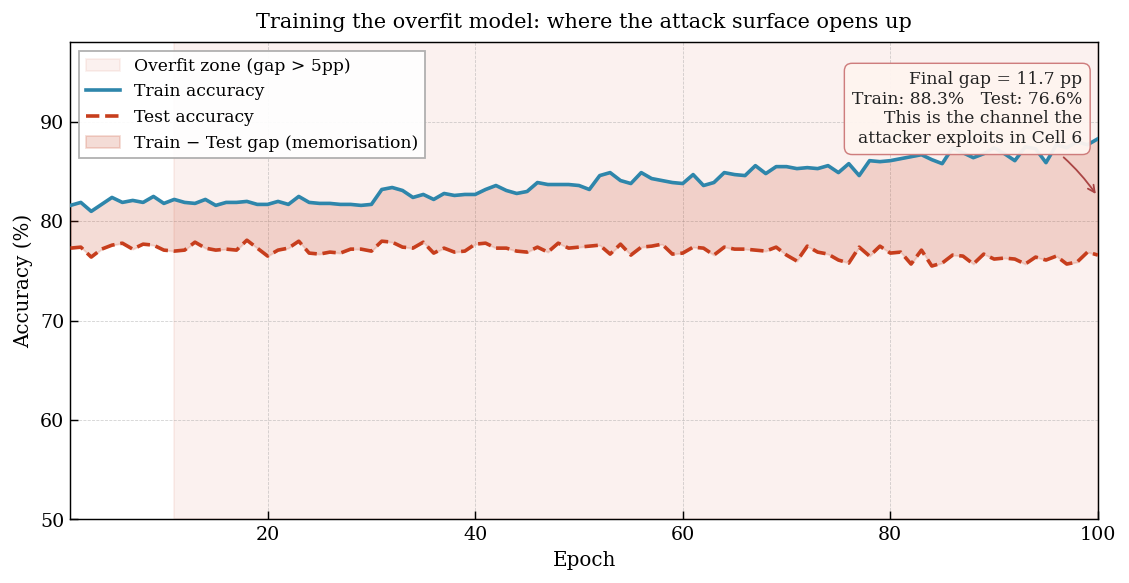

Final train accuracy : 88.30%
Final test accuracy  : 76.60%
Accuracy gap         : 11.70 percentage points
Overfit zone opens at epoch ~11 (gap first exceeds 5pp)

This gap is the attack surface for membership inference.


In [15]:
# Cell 3: Train the overfit model and plot the accuracy gap
overfit_model = RiskMLP().to(device)
tr_accs, te_accs = train_model(
    overfit_model, train_loader, epochs=100,
    eval_data=(X_tr, y_tr, X_te, y_te),
)

epochs = np.arange(1, len(tr_accs) + 1)
tr_pct = np.array(tr_accs) * 100
te_pct = np.array(te_accs) * 100
gap_pct = tr_pct - te_pct

OVERFIT_THRESH_PP = 5.0
onset_idx = next((i for i, g in enumerate(gap_pct) if g > OVERFIT_THRESH_PP),
                 len(gap_pct) - 1)
onset_epoch = int(epochs[onset_idx])

fig, ax = plt.subplots(figsize=(8.8, 4.6))

ax.axvspan(onset_epoch, epochs[-1], color=OVERFIT_COLOR, alpha=0.07, zorder=0,
           label=f'Overfit zone (gap > {OVERFIT_THRESH_PP:.0f}pp)')
ax.plot(epochs, tr_pct, color=MEMBER_COLOR,    lw=2.0, label='Train accuracy', zorder=3)
ax.plot(epochs, te_pct, color=NONMEMBER_COLOR, lw=2.0, ls='--',
        label='Test accuracy', zorder=3)
ax.fill_between(epochs, te_pct, tr_pct,
                where=(tr_pct >= te_pct), interpolate=True,
                color=OVERFIT_COLOR, alpha=0.18, zorder=2,
                label='Train − Test gap (memorisation)')

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_xlim(epochs[0], epochs[-1])
ax.set_ylim(min(50, te_pct.min() - 3), 98)
ax.set_title('Training the overfit model: where the attack surface opens up',
             pad=8)
_grid(ax, 'both')
ax.legend(loc='upper left', fontsize=9.5)

gap_final = gap_pct[-1]
ax.annotate(
    f'Final gap = {gap_final:.1f} pp\n'
    f'Train: {tr_pct[-1]:.1f}%   Test: {te_pct[-1]:.1f}%\n'
    'This is the channel the\nattacker exploits next',
    xy=(epochs[-1], (tr_pct[-1] + te_pct[-1]) / 2),
    xytext=(0.985, 0.94), textcoords='axes fraction',
    fontsize=9.5, ha='right', va='top', color='#222222',
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#FFF5F0',
              edgecolor='#CC7777', linewidth=0.8, alpha=0.95),
    arrowprops=dict(arrowstyle='->', color='#AA4444', lw=1.0,
                    connectionstyle='arc3,rad=-0.2'))

plt.tight_layout(); plt.show()

print(f'Final train accuracy : {tr_accs[-1]*100:.2f}%')
print(f'Final test accuracy  : {te_accs[-1]*100:.2f}%')
print(f'Accuracy gap         : {gap_final:.2f} percentage points')
print(f'Overfit zone opens at epoch ~{onset_epoch} '
      f'(gap first exceeds {OVERFIT_THRESH_PP:.0f}pp)')
print()
print('This gap is the attack surface for membership inference.')


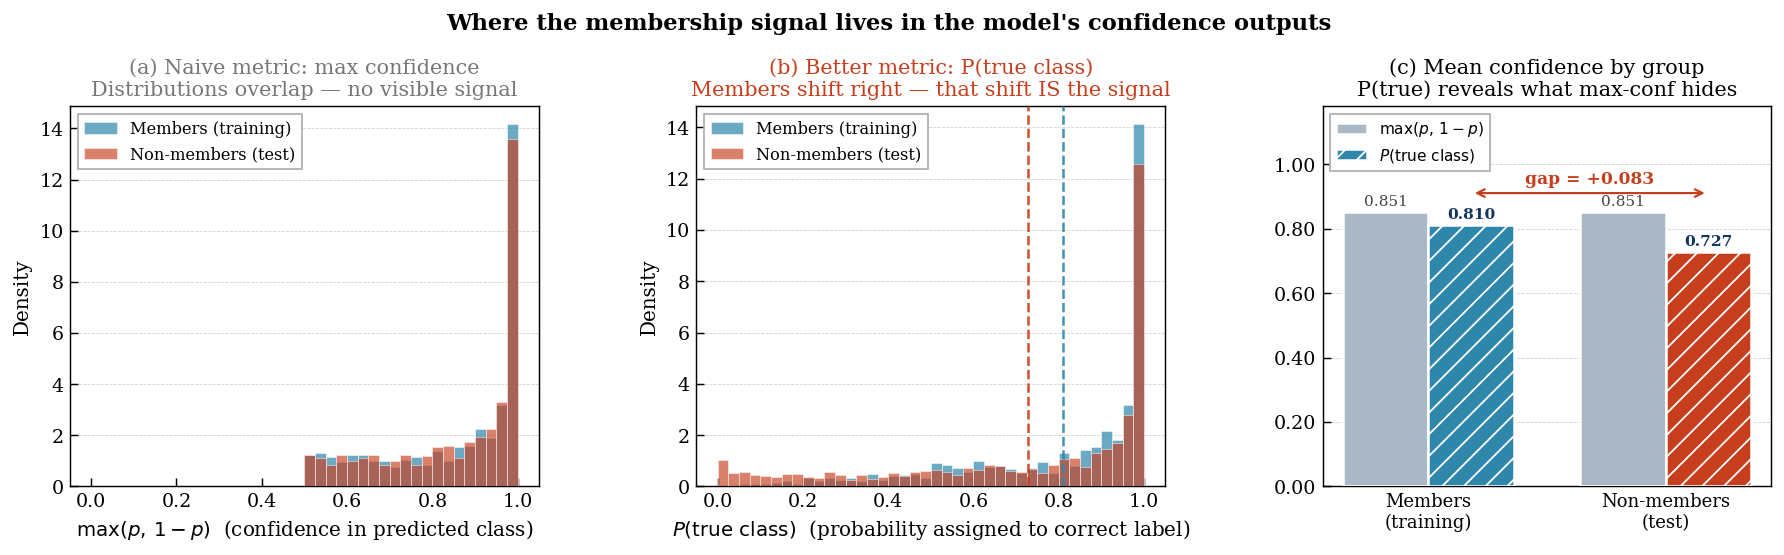

max(p, 1-p)         -- gap : -0.0001
P(true class)       -- gap : +0.0833

The first metric is dead because the overfit model is also "confidently
wrong" on test points. The second metric is asymmetric and carries the
membership signal that the Cell 6 attack will exploit.


In [16]:
# Cell 4: Where the membership signal lives in the model's outputs
conf_train = predict_proba(overfit_model, X_tr)
conf_test  = predict_proba(overfit_model, X_te)

# max-confidence stays high even when the model is wrong, so it doesn't
# distinguish members from non-members. P(true class) drops on
# misclassifications, which is what the attack actually picks up on.
max_conf_train = np.maximum(conf_train, 1 - conf_train)
max_conf_test  = np.maximum(conf_test,  1 - conf_test)

p_true_train = np.where(y_train > 0.5, conf_train, 1 - conf_train)
p_true_test  = np.where(y_test  > 0.5, conf_test,  1 - conf_test)

fig = plt.figure(figsize=(14.0, 4.5))
gs  = GridSpec(1, 3, width_ratios=[1.15, 1.15, 1.10],
               left=0.05, right=0.985, top=0.83, bottom=0.18, wspace=0.34)

bins = np.linspace(0, 1, 41)

ax = fig.add_subplot(gs[0, 0])
ax.hist(max_conf_train, bins=bins, color=MEMBER_COLOR,    alpha=0.70,
        edgecolor='white', linewidth=0.4,
        label='Members (training)', density=True, zorder=3)
ax.hist(max_conf_test,  bins=bins, color=NONMEMBER_COLOR, alpha=0.65,
        edgecolor='white', linewidth=0.4,
        label='Non-members (test)', density=True, zorder=3)
ax.set_xlabel(r'$\max(p,\, 1-p)$  (confidence in predicted class)')
ax.set_ylabel('Density')
ax.set_title('(a) Naive metric: max confidence\n'
             'Distributions overlap — no visible signal',
             pad=6, color='#777777')
ax.legend(loc='upper left', fontsize=9)
_grid(ax, 'y')

ax = fig.add_subplot(gs[0, 1])
ax.hist(p_true_train, bins=bins, color=MEMBER_COLOR,    alpha=0.70,
        edgecolor='white', linewidth=0.4,
        label='Members (training)', density=True, zorder=3)
ax.hist(p_true_test,  bins=bins, color=NONMEMBER_COLOR, alpha=0.65,
        edgecolor='white', linewidth=0.4,
        label='Non-members (test)', density=True, zorder=3)
ax.axvline(p_true_train.mean(), color=MEMBER_COLOR,    ls='--', lw=1.4,
           alpha=0.9, zorder=4)
ax.axvline(p_true_test.mean(),  color=NONMEMBER_COLOR, ls='--', lw=1.4,
           alpha=0.9, zorder=4)
ax.set_xlabel(r'$P(\mathrm{true~class})$  (probability assigned to correct label)')
ax.set_ylabel('Density')
ax.set_title('(b) Better metric: P(true class)\n'
             'Members shift right — that shift IS the signal',
             pad=6, color=OVERFIT_COLOR)
ax.legend(loc='upper left', fontsize=9)
_grid(ax, 'y')

ax = fig.add_subplot(gs[0, 2])
labels = ['Members\n(training)', 'Non-members\n(test)']
means_max = [max_conf_train.mean(), max_conf_test.mean()]
means_pt  = [p_true_train.mean(),   p_true_test.mean()]

x     = np.arange(len(labels))
width = 0.36
b1 = ax.bar(x - width/2, means_max, width, color='#AAB7C4',
            edgecolor='white', linewidth=1.4,
            label=r'$\max(p,\, 1-p)$', zorder=3)
b2 = ax.bar(x + width/2, means_pt,  width, color=[MEMBER_COLOR, NONMEMBER_COLOR],
            edgecolor='white', linewidth=1.4, hatch='//',
            label=r'$P(\mathrm{true~class})$', zorder=3)

for b, v in zip(b1, means_max):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012, f'{v:.3f}',
            ha='center', va='bottom', fontsize=8.5, color='#444444')
for b, v in zip(b2, means_pt):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012, f'{v:.3f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color='#13365F')

gap_value = p_true_train.mean() - p_true_test.mean()
ymax = max(means_pt) + 0.10
ax.annotate('', xy=(x[0] + width/2, ymax), xytext=(x[1] + width/2, ymax),
            arrowprops=dict(arrowstyle='<->', color=OVERFIT_COLOR, lw=1.2))
ax.text(np.mean(x) + width/2, ymax + 0.018,
        f'gap = {gap_value:+.3f}',
        ha='center', va='bottom', fontsize=9.5, fontweight='bold',
        color=OVERFIT_COLOR)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.18)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_title('(c) Mean confidence by group\n'
             'P(true) reveals what max-conf hides',
             pad=6)
ax.legend(loc='upper left', fontsize=8.5)
_grid(ax, 'y')

fig.suptitle('Where the membership signal lives in the model\'s confidence outputs',
             fontsize=12.5, fontweight='bold', y=0.99)
plt.show()

print(f'max(p, 1-p)         -- gap : {max_conf_train.mean()-max_conf_test.mean():+.4f}')
print(f'P(true class)       -- gap : {p_true_train.mean()-p_true_test.mean():+.4f}')


In [17]:
# Cell 5: Train a shadow model on held-out data
# Local RNG so we don't disturb the global numpy state.
rng = np.random.default_rng(99)

X_shadow_risk   = (rng.standard_normal((N//2, N_FEAT)) + RISK_MEAN).astype(np.float32)
X_shadow_norisk = (rng.standard_normal((N//2, N_FEAT)) + NORISK_MEAN).astype(np.float32)
X_shadow        = np.vstack([X_shadow_risk, X_shadow_norisk])
y_shadow        = np.concatenate([np.ones(N//2, dtype=np.float32),
                                  np.zeros(N//2, dtype=np.float32)])

X_sh_tr, X_sh_te, y_sh_tr, y_sh_te = train_test_split(
    X_shadow, y_shadow, test_size=0.50, random_state=42, stratify=y_shadow
)
# Same preprocessing as the target model.
X_sh_tr = scaler.transform(X_sh_tr.astype(np.float32))
X_sh_te = scaler.transform(X_sh_te.astype(np.float32))

sh_tr_tensor = torch.tensor(X_sh_tr, dtype=torch.float32)
sh_te_tensor = torch.tensor(X_sh_te, dtype=torch.float32)
y_sh_tr_t    = torch.tensor(y_sh_tr, dtype=torch.float32)

sh_loader = DataLoader(TensorDataset(sh_tr_tensor, y_sh_tr_t),
                        batch_size=32, shuffle=True)

shadow_model = RiskMLP().to(device)
print('Training shadow model...')
train_model(shadow_model, sh_loader, epochs=100, verbose=False)
print('Shadow model trained.')


Training shadow model...
Shadow model trained.


Attack model trained on shadow model outputs.

Attack accuracy   : 55.80%
Random baseline   : 50.00%
Attack advantage  : 0.1160

An advantage of 0.12 means the attacker learns substantial
information about membership beyond random guessing.
Even a small advantage is a privacy violation at scale.


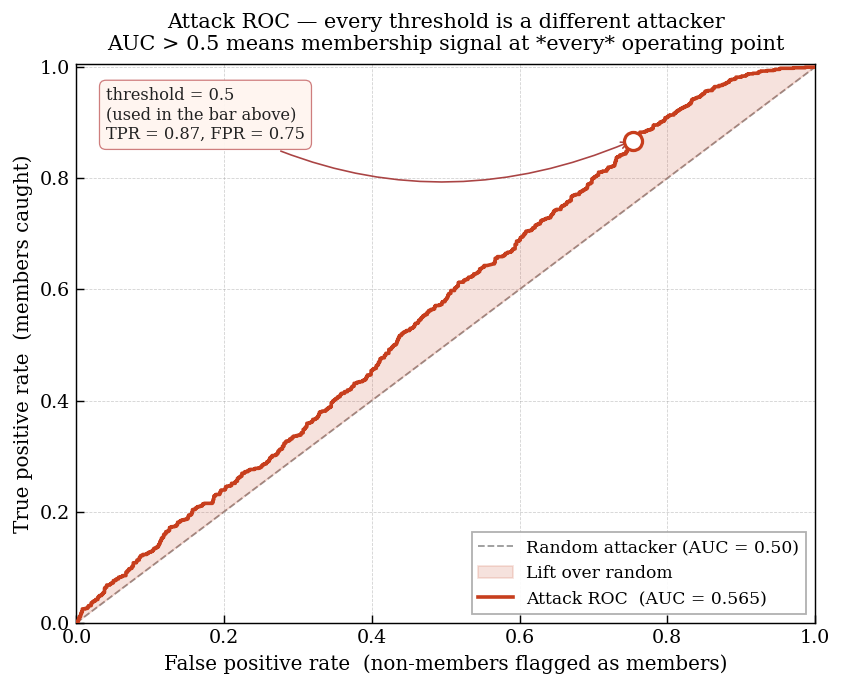


ROC AUC : 0.5648   (0.5 = no signal,  1.0 = perfect attacker)


In [18]:
# Cell 6: Build the attack dataset and train the attack classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

def attack_features(probs, labels):
    """Convert P(y=1) and the true label into MIA attack features.

    Threat model (Shokri et al. 2017): the attacker holds a candidate
    (x, y) pair and asks whether it was in training, so the true label
    is part of their input.

    Returns [BCE loss, 1 - P(true class)]; both are small for members
    that the model fits well, large for non-members it generalises to
    badly.
    """
    eps = 1e-7
    p = np.clip(probs, eps, 1 - eps)
    p_true = np.where(labels > 0.5, p, 1 - p)
    loss   = -np.log(p_true)
    return np.column_stack([loss, 1 - p_true])

conf_sh_train = predict_proba(shadow_model, sh_tr_tensor)
conf_sh_test  = predict_proba(shadow_model, sh_te_tensor)

attack_X = np.vstack([attack_features(conf_sh_train, y_sh_tr),
                      attack_features(conf_sh_test,  y_sh_te)])
attack_y = np.array([1]*len(conf_sh_train) + [0]*len(conf_sh_test))

attack_model = LogisticRegression(max_iter=1000)
attack_model.fit(attack_X, attack_y)
print('Attack model trained on shadow model outputs.')

conf_real_train = predict_proba(overfit_model, X_tr)
conf_real_test  = predict_proba(overfit_model, X_te)

real_attack_X = np.vstack([attack_features(conf_real_train, y_train),
                           attack_features(conf_real_test,  y_test)])
real_attack_y = np.array([1]*len(conf_real_train) + [0]*len(conf_real_test))

attack_preds  = attack_model.predict(real_attack_X)
attack_scores = attack_model.predict_proba(real_attack_X)[:, 1]
attack_acc    = accuracy_score(real_attack_y, attack_preds)
advantage     = 2 * (attack_acc - 0.5)

print(f'\nAttack accuracy   : {attack_acc*100:.2f}%')
print(f'Random baseline   : 50.00%')
print(f'Attack advantage  : {advantage:.4f}')
print()
if advantage <= 0.01:
    print('Attack advantage is essentially zero: the attacker has not learned')
    print('to distinguish members from non-members. The model leaks no membership')
    print('information through its confidence scores in this setting.')
elif advantage < 0.10:
    print(f'A small advantage of {advantage:.2f} still constitutes a privacy leak')
    print('at scale: across many queries, the attacker reliably does better')
    print('than chance.')
else:
    print(f'An advantage of {advantage:.2f} means the attacker learns substantial')
    print('information about membership beyond random guessing.')
    print('Even a small advantage is a privacy violation at scale.')

# ── Figure: attacker ROC across all decision thresholds ────────────────
fpr, tpr, thresholds = roc_curve(real_attack_y, attack_scores)
roc_auc = auc(fpr, tpr)
op_idx  = int(np.argmin(np.abs(thresholds - 0.5)))
op_fpr, op_tpr = fpr[op_idx], tpr[op_idx]

fig, ax = plt.subplots(figsize=(6.6, 5.4))

ax.plot([0, 1], [0, 1], color=GRID_COLOR, ls='--', lw=1.0, zorder=1,
        label='Random attacker (AUC = 0.50)')
ax.fill_between(fpr, fpr, tpr, where=(tpr >= fpr),
                color=OVERFIT_COLOR, alpha=0.15, zorder=2,
                label='Lift over random')
ax.plot(fpr, tpr, color=OVERFIT_COLOR, lw=2.0, zorder=3,
        label=f'Attack ROC  (AUC = {roc_auc:.3f})')
ax.plot([op_fpr], [op_tpr], marker='o', markersize=10,
        markerfacecolor='#FFFFFF', markeredgecolor=OVERFIT_COLOR,
        markeredgewidth=1.8, zorder=4)

ax.annotate(
    f'threshold = 0.5\n(used in the bar above)\n'
    f'TPR = {op_tpr:.2f}, FPR = {op_fpr:.2f}',
    xy=(op_fpr, op_tpr),
    xytext=(0.04, 0.96), textcoords='axes fraction',
    fontsize=9, ha='left', va='top', color='#222222',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF5F0',
              edgecolor='#CC7777', linewidth=0.7, alpha=0.95),
    arrowprops=dict(arrowstyle='->', color='#AA4444', lw=0.9,
                    connectionstyle='arc3,rad=0.25'))

ax.set_xlim(0, 1); ax.set_ylim(0, 1.005)
ax.set_xlabel('False positive rate  (non-members flagged as members)')
ax.set_ylabel('True positive rate  (members caught)')
ax.set_title('Attack ROC — every threshold is a different attacker\n'
             'AUC > 0.5 means membership signal at *every* operating point',
             pad=8)
ax.legend(loc='lower right', fontsize=9.5)
_grid(ax, 'both')

plt.tight_layout(); plt.show()

print(f'\nROC AUC : {roc_auc:.4f}   (0.5 = no signal,  1.0 = perfect attacker)')


In [19]:
# Cell 7: Train with L2 regularization and early stopping
import copy

def train_with_regularization(weight_decay=0.01, patience=15, max_epochs=200):
    """L2 weight decay + early stopping on the validation set.

    Early stopping uses X_va, never the test set -- selecting weights by
    test accuracy would leak the test signal into the model.
    """
    model      = RiskMLP().to(device)
    opt        = torch.optim.AdamW(model.parameters(), lr=0.001,
                                    weight_decay=weight_decay)
    criterion  = nn.BCEWithLogitsLoss()
    best_acc   = -1.0                       # ensures best_wts is set on epoch 0
    best_wts   = copy.deepcopy(model.state_dict())
    no_improve = 0
    final_epoch = 0

    for epoch in range(max_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            opt.zero_grad()
            criterion(model(X_batch), y_batch).backward()
            opt.step()

        val_acc = accuracy(model, X_va, y_va)
        final_epoch = epoch + 1

        if val_acc > best_acc:
            best_acc   = val_acc
            best_wts   = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {final_epoch} '
                      f'(best val acc: {best_acc*100:.1f}%)')
                break

    model.load_state_dict(best_wts)
    return model, final_epoch

print('Training regularized model...')
reg_model, stopped_epoch = train_with_regularization(weight_decay=0.01, patience=15)

reg_tr_acc = accuracy(reg_model, X_tr, y_tr)
reg_te_acc = accuracy(reg_model, X_te, y_te)

print(f'Stopped at epoch:  {stopped_epoch}')
print(f'Train accuracy:    {reg_tr_acc*100:.2f}%')
print(f'Test accuracy:     {reg_te_acc*100:.2f}%')
print(f'Gap:               {(reg_tr_acc-reg_te_acc)*100:.2f} pp')


Training regularized model...
  Early stopping at epoch 17 (best val acc: 81.5%)
Stopped at epoch:  17
Train accuracy:    81.60%
Test accuracy:     78.10%
Gap:               3.50 pp


In [20]:
# Cell 8: Re-run the same attack on the regularized model
conf_reg_train = predict_proba(reg_model, X_tr)
conf_reg_test  = predict_proba(reg_model, X_te)

reg_attack_X = np.vstack([attack_features(conf_reg_train, y_train),
                          attack_features(conf_reg_test,  y_test)])
reg_preds = attack_model.predict(reg_attack_X)
reg_acc   = accuracy_score(real_attack_y, reg_preds)
reg_adv   = 2 * (reg_acc - 0.5)

print(f'Attack on regularized model:')
print(f'  Attack accuracy  : {reg_acc*100:.2f}%')
print(f'  Attack advantage : {reg_adv:.4f}')
print()
print(f'{"Model":<26} {"Train":>8} {"Test":>8} {"Gap":>7} {"Adv":>8}')
print('-' * 62)
gap_o = (tr_accs[-1] - te_accs[-1]) * 100
gap_r = (reg_tr_acc - reg_te_acc) * 100
print(f'{"Overfit (no defense)":<26} {tr_accs[-1]*100:>7.1f}% '
      f'{te_accs[-1]*100:>7.1f}% {gap_o:>6.1f}pp {advantage:>8.4f}')
print(f'{"Regularized":<26} {reg_tr_acc*100:>7.1f}% '
      f'{reg_te_acc*100:>7.1f}% {gap_r:>6.1f}pp {reg_adv:>8.4f}')


Attack on regularized model:
  Attack accuracy  : 51.70%
  Attack advantage : 0.0340

Model                         Train     Test     Gap      Adv
--------------------------------------------------------------
Overfit (no defense)          88.3%    76.6%   11.7pp   0.1160
Regularized                   81.6%    78.1%    3.5pp   0.0340


In [21]:
# Cell 9: Install Opacus (PyTorch's differential privacy library)
# Uses the %pip magic so the install runs in the kernel's own environment;
# subprocess.run can hang inside Jupyter.
try:
    from opacus import PrivacyEngine
    from opacus.validators import ModuleValidator
    print('Opacus is available.')
except ImportError:
    print('Installing opacus into the current kernel...')
    %pip install --quiet opacus
    from opacus import PrivacyEngine
    from opacus.validators import ModuleValidator
    print('Opacus installed and imported.')


Opacus is available.


In [22]:
# Cell 10: Train with DP-SGD
# ⚠️ Per-sample gradients make this 2-3× slower than plain SGD. With
#    epochs=50 on CPU, expect 5-10 minutes.

def train_with_dp(target_epsilon=5.0, target_delta=1e-5,
                  max_grad_norm=1.0, epochs=50):
    """Train a RiskMLP with differential privacy via Opacus DP-SGD.

    target_epsilon : privacy budget (smaller = more private, less accurate)
    target_delta   : failure probability; typically 1/N_train
    max_grad_norm  : per-sample gradient clipping bound
    """
    from opacus import PrivacyEngine
    from opacus.validators import ModuleValidator

    dp_model  = RiskMLP().to(device)
    dp_model  = ModuleValidator.fix(dp_model)
    optimizer = torch.optim.SGD(dp_model.parameters(), lr=0.05)
    criterion = nn.BCEWithLogitsLoss()

    privacy_engine = PrivacyEngine()
    dp_model, optimizer, dp_train_loader = privacy_engine.make_private_with_epsilon(
        module=dp_model,
        optimizer=optimizer,
        data_loader=train_loader,
        epochs=epochs,
        target_epsilon=target_epsilon,
        target_delta=target_delta,
        max_grad_norm=max_grad_norm,
    )
    print(f'DP-SGD configured.  Target ε = {target_epsilon},  δ = {target_delta}')

    for epoch in range(epochs):
        dp_model.train()
        for X_batch, y_batch in dp_train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            criterion(dp_model(X_batch), y_batch).backward()
            optimizer.step()

        if (epoch + 1) % 10 == 0:
            eps = privacy_engine.get_epsilon(target_delta)
            te_acc = accuracy(dp_model, X_te, y_te)
            print(f'  Epoch {epoch+1:3d}  |  ε = {eps:.2f}  |  '
                  f'test acc = {te_acc*100:.1f}%')

    achieved_epsilon = privacy_engine.get_epsilon(target_delta)
    print(f'\nFinal privacy budget spent: ε = {achieved_epsilon:.3f}')
    return dp_model, achieved_epsilon

print('Training with DP-SGD (target epsilon = 5.0)...')
dp_model_5, eps_5 = train_with_dp(target_epsilon=5.0, epochs=50)


Training with DP-SGD (target epsilon = 5.0)...


/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


DP-SGD configured.  Target ε = 5.0,  δ = 1e-05
  Epoch  10  |  ε = 2.14  |  test acc = 76.9%
  Epoch  20  |  ε = 3.05  |  test acc = 77.4%
  Epoch  30  |  ε = 3.78  |  test acc = 77.1%
  Epoch  40  |  ε = 4.42  |  test acc = 77.6%
  Epoch  50  |  ε = 5.00  |  test acc = 77.3%

Final privacy budget spent: ε = 4.999


Model                             Train     Test     Gap      Adv
--------------------------------------------------------------------
Overfit (no defense)              88.3%    76.6%   11.7pp   0.1160
Regularized                       81.6%    78.1%    3.5pp   0.0340
DP-SGD (ε=5.0)                    81.7%    77.3%    4.4pp   0.0410


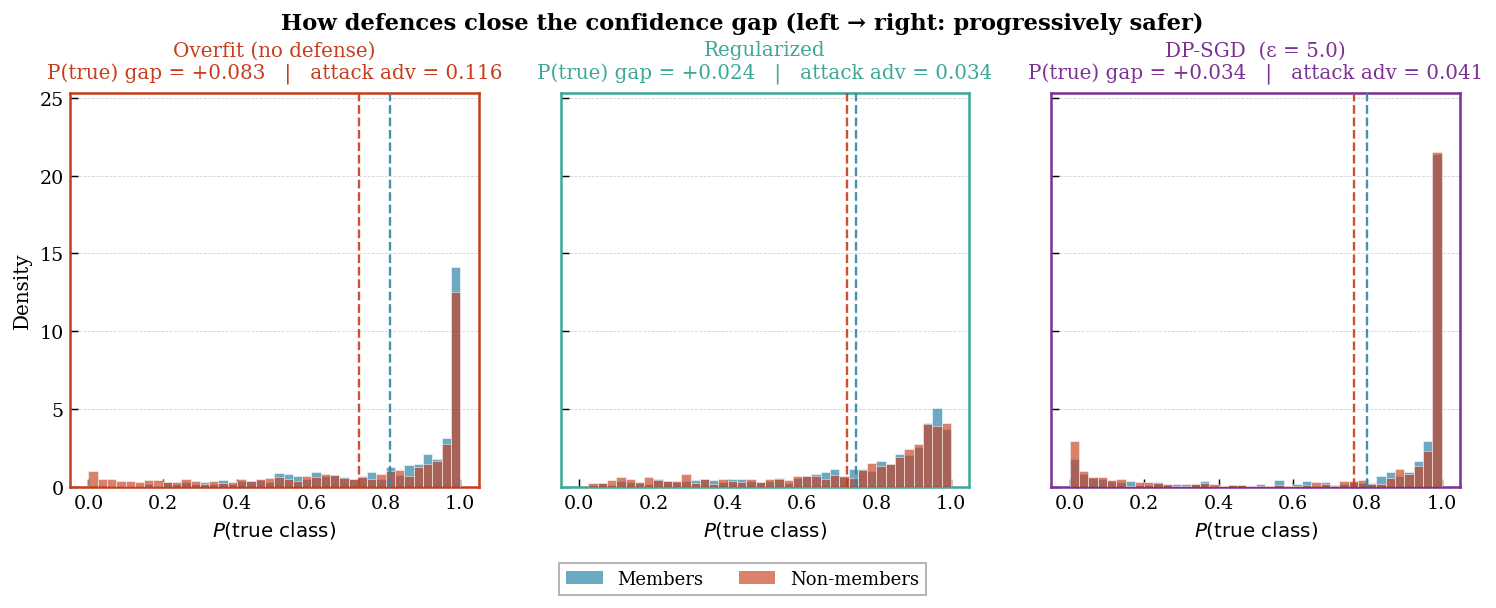

In [23]:
# Cell 11: Evaluate all three models side by side
def evaluate_model(model, return_scores=False):
    """Returns (train_acc, test_acc, attack_advantage); with return_scores=True
    also returns the per-sample P(true class) arrays used by the figure."""
    tr_acc = accuracy(model, X_tr, y_tr)
    te_acc = accuracy(model, X_te, y_te)
    c_tr   = predict_proba(model, X_tr)
    c_te   = predict_proba(model, X_te)

    atk_X = np.vstack([attack_features(c_tr, y_train),
                       attack_features(c_te, y_test)])
    preds = attack_model.predict(atk_X)
    adv   = 2 * (accuracy_score(real_attack_y, preds) - 0.5)

    if return_scores:
        pt_tr = np.where(y_train > 0.5, c_tr, 1 - c_tr)
        pt_te = np.where(y_test  > 0.5, c_te, 1 - c_te)
        return tr_acc, te_acc, adv, pt_tr, pt_te
    return tr_acc, te_acc, adv

tr5, te5, adv5, pt_tr_dp,  pt_te_dp  = evaluate_model(dp_model_5,  return_scores=True)
_,   _,   _,    pt_tr_ovr, pt_te_ovr = evaluate_model(overfit_model, return_scores=True)
_,   _,   _,    pt_tr_reg, pt_te_reg = evaluate_model(reg_model,    return_scores=True)

print(f'{"Model":<30} {"Train":>8} {"Test":>8} {"Gap":>7} {"Adv":>8}')
print('-' * 68)
for name, tra, tea, adv in [
    ('Overfit (no defense)',       tr_accs[-1], te_accs[-1], advantage),
    ('Regularized',                reg_tr_acc,  reg_te_acc,  reg_adv),
    (f'DP-SGD (ε={eps_5:.1f})',    tr5,         te5,         adv5),
]:
    gap = (tra - tea) * 100
    print(f'{name:<30} {tra*100:>7.1f}% {tea*100:>7.1f}% '
          f'{gap:>6.1f}pp {adv:>8.4f}')

# ── Figure: P(true) distribution under each defense ────────────────────
panels = [
    ('Overfit (no defense)',       OVERFIT_COLOR, pt_tr_ovr, pt_te_ovr, advantage),
    ('Regularized',                REG_COLOR,     pt_tr_reg, pt_te_reg, reg_adv),
    (f'DP-SGD  (ε = {eps_5:.1f})', DP_COLOR,      pt_tr_dp,  pt_te_dp,  adv5),
]

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.6),
                         sharex=True, sharey=True)
bins = np.linspace(0, 1, 41)

for ax, (name, frame_c, pt_m, pt_n, adv) in zip(axes, panels):
    ax.hist(pt_m, bins=bins, color=MEMBER_COLOR,    alpha=0.70,
            edgecolor='white', linewidth=0.4, density=True, zorder=3,
            label='Members')
    ax.hist(pt_n, bins=bins, color=NONMEMBER_COLOR, alpha=0.65,
            edgecolor='white', linewidth=0.4, density=True, zorder=3,
            label='Non-members')
    ax.axvline(pt_m.mean(), color=MEMBER_COLOR,    ls='--', lw=1.3, alpha=0.9, zorder=4)
    ax.axvline(pt_n.mean(), color=NONMEMBER_COLOR, ls='--', lw=1.3, alpha=0.9, zorder=4)

    gap = pt_m.mean() - pt_n.mean()
    ax.set_title(f'{name}\nP(true) gap = {gap:+.3f}   |   attack adv = {adv:.3f}',
                 pad=8, color=frame_c, fontsize=11)
    ax.set_xlabel(r'$P(\mathrm{true~class})$')
    _grid(ax, 'y')
    for sp in ax.spines.values():
        sp.set_color(frame_c); sp.set_linewidth(1.4)

axes[0].set_ylabel('Density')

ymax_hi = max(ax.get_ylim()[1] for ax in axes) * 1.12
for ax in axes:
    ax.set_ylim(0, ymax_hi)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor=MEMBER_COLOR,    alpha=0.70, label='Members'),
                    Patch(facecolor=NONMEMBER_COLOR, alpha=0.65, label='Non-members')],
           loc='lower center', bbox_to_anchor=(0.5, 0.005),
           ncol=2, fontsize=10, frameon=True,
           framealpha=0.95, edgecolor='#aaaaaa')

fig.suptitle('How defences close the confidence gap '
             '(left → right: progressively safer)',
             fontsize=12.5, fontweight='bold', y=0.995)
fig.subplots_adjust(top=0.86, bottom=0.20)
plt.show()



--- target ε = 0.1 ---


/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


DP-SGD configured.  Target ε = 0.1,  δ = 1e-05
  Epoch  10  |  ε = 0.04  |  test acc = 54.9%
  Epoch  20  |  ε = 0.06  |  test acc = 64.8%
  Epoch  30  |  ε = 0.07  |  test acc = 64.0%
  Epoch  40  |  ε = 0.08  |  test acc = 70.8%
  Epoch  50  |  ε = 0.09  |  test acc = 62.1%

Final privacy budget spent: ε = 0.094
  seed 0: ε=0.09  test=62.1%  adv=-0.055


/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


DP-SGD configured.  Target ε = 0.1,  δ = 1e-05
  Epoch  10  |  ε = 0.04  |  test acc = 63.9%
  Epoch  20  |  ε = 0.06  |  test acc = 59.9%
  Epoch  30  |  ε = 0.07  |  test acc = 62.8%
  Epoch  40  |  ε = 0.08  |  test acc = 67.6%
  Epoch  50  |  ε = 0.09  |  test acc = 65.7%

Final privacy budget spent: ε = 0.094
  seed 1: ε=0.09  test=65.7%  adv=-0.008


...

DP-SGD configured.  Target ε = 10.0,  δ = 1e-05
  Epoch  10  |  ε = 4.41  |  test acc = 77.6%
  Epoch  20  |  ε = 6.15  |  test acc = 77.2%
  Epoch  30  |  ε = 7.58  |  test acc = 77.6%
  Epoch  40  |  ε = 8.84  |  test acc = 77.6%
  Epoch  50  |  ε = 10.00  |  test acc = 77.6%

Final privacy budget spent: ε = 9.997
  seed 0: ε=10.00  test=77.6%  adv=0.039


/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


DP-SGD configured.  Target ε = 10.0,  δ = 1e-05
  Epoch  10  |  ε = 4.41  |  test acc = 77.5%
  Epoch  20  |  ε = 6.15  |  test acc = 77.5%
  Epoch  30  |  ε = 7.58  |  test acc = 77.3%
  Epoch  40  |  ε = 8.84  |  test acc = 77.2%
  Epoch  50  |  ε = 10.00  |  test acc = 77.6%

Final privacy budget spent: ε = 9.997
  seed 1: ε=10.00  test=77.6%  adv=0.042


/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/data/short/pchen15/conda_envs/FirstPaper/lib/python3.10/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


DP-SGD configured.  Target ε = 10.0,  δ = 1e-05
  Epoch  10  |  ε = 4.41  |  test acc = 77.0%
  Epoch  20  |  ε = 6.15  |  test acc = 77.3%
  Epoch  30  |  ε = 7.58  |  test acc = 77.7%
  Epoch  40  |  ε = 8.84  |  test acc = 78.0%
  Epoch  50  |  ε = 10.00  |  test acc = 77.4%

Final privacy budget spent: ε = 9.997
  seed 2: ε=10.00  test=77.4%  adv=0.053

=== Median across 3 seeds ===
   eps   test%     adv
  0.09    65.7  -0.008
  0.29    68.6   0.022
  0.50    73.1   0.021
  1.00    77.0   0.029
  1.99    77.2   0.043
  5.00    77.4   0.047
 10.00    77.6   0.042


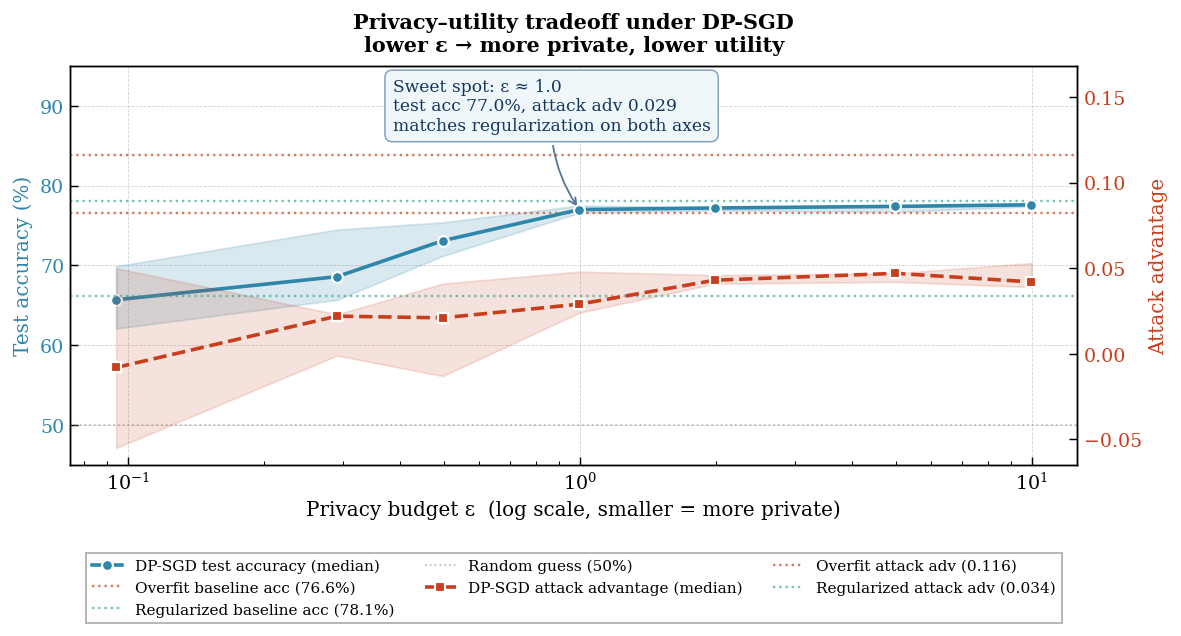

In [24]:
# Cell 12: Epsilon sweep — the privacy-utility tradeoff curve
#
# ⚠️ Runtime: 7 epsilons × 3 seeds × ~1 min ≈ 20 min on CPU. Drop
#    N_SEEDS to 1 for a quick smoke test.
#
# Each ε is averaged over multiple seeds: at small ε the gradient noise
# dominates, so single runs swing wildly and only the median traces the
# real shape of the tradeoff.
epsilons_to_test = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]
N_SEEDS = 3
all_runs = {eps: [] for eps in epsilons_to_test}

for eps_target in epsilons_to_test:
    print(f'\n--- target ε = {eps_target} ---')
    for s in range(N_SEEDS):
        torch.manual_seed(1234 + s); np.random.seed(1234 + s)
        m, eps_achieved = train_with_dp(target_epsilon=eps_target, epochs=50)
        _, te_a, adv = evaluate_model(m)
        all_runs[eps_target].append((eps_achieved, te_a, adv))
        print(f'  seed {s}: ε={eps_achieved:.2f}  test={te_a*100:.1f}%  adv={adv:.3f}')

def med(xs): return float(np.median(xs))
results = []
for eps_target in epsilons_to_test:
    runs = all_runs[eps_target]
    results.append((
        med([r[0] for r in runs]),
        med([r[1] for r in runs]),
        med([r[2] for r in runs]),
        min(r[1] for r in runs), max(r[1] for r in runs),
        min(r[2] for r in runs), max(r[2] for r in runs),
    ))

print('\n=== Median across', N_SEEDS, 'seeds ===')
print(f'{"eps":>6}  {"test%":>6}  {"adv":>6}')
for r in results:
    print(f'{r[0]:>6.2f}  {r[1]*100:>6.1f}  {r[2]:>6.3f}')

# ── Figure: privacy-utility tradeoff with reference baselines ────────────
eps_vals     = [r[0] for r in results]
dp_test_accs = [r[1]*100 for r in results]
dp_advs      = [r[2] for r in results]
te_band_lo   = [r[3]*100 for r in results]
te_band_hi   = [r[4]*100 for r in results]
ad_band_lo   = [r[5] for r in results]
ad_band_hi   = [r[6] for r in results]

fig, ax1 = plt.subplots(figsize=(9.2, 5.2))
ax2 = ax1.twinx()

ax1.fill_between(eps_vals, te_band_lo, te_band_hi,
                 color=MEMBER_COLOR, alpha=0.18, zorder=2)
ax2.fill_between(eps_vals, ad_band_lo, ad_band_hi,
                 color=NONMEMBER_COLOR, alpha=0.15, zorder=2)

l1, = ax1.plot(eps_vals, dp_test_accs, 'o-', color=MEMBER_COLOR, lw=2.0,
               markersize=6, markeredgecolor='white', markeredgewidth=1.2,
               zorder=4, label='DP-SGD test accuracy (median)')
l2, = ax2.plot(eps_vals, dp_advs,      's--', color=NONMEMBER_COLOR, lw=2.0,
               markersize=6, markeredgecolor='white', markeredgewidth=1.2,
               zorder=4, label='DP-SGD attack advantage (median)')

ax1.axhline(te_accs[-1]*100, color=OVERFIT_COLOR, ls=':', lw=1.3, alpha=0.7,
            label=f'Overfit baseline acc ({te_accs[-1]*100:.1f}%)')
ax1.axhline(reg_te_acc*100, color=REG_COLOR, ls=':', lw=1.3, alpha=0.7,
            label=f'Regularized baseline acc ({reg_te_acc*100:.1f}%)')
ax1.axhline(50.0, color=GRID_COLOR, ls=':', lw=1.0, alpha=0.6,
            label='Random guess (50%)')
ax2.axhline(advantage, color=OVERFIT_COLOR, ls=':', lw=1.3, alpha=0.7,
            label=f'Overfit attack adv ({advantage:.3f})')
ax2.axhline(reg_adv,   color=REG_COLOR,    ls=':', lw=1.3, alpha=0.7,
            label=f'Regularized attack adv ({reg_adv:.3f})')

ax1_lo = min(45, min(te_band_lo) - 4)
ax1_hi = max(95, te_accs[-1]*100 + 14)
ax1.set_ylim(ax1_lo, ax1_hi)
ax2_lo = min(-0.02, min(ad_band_lo) - 0.01)
ax2_hi = max(advantage, max(ad_band_hi)) * 1.45
ax2.set_ylim(ax2_lo, ax2_hi)

# Sweet spot: the largest ε whose attack advantage is roughly at the
# regularized baseline -- best accuracy you can buy at that privacy level.
sweet_idx = max((i for i, a in enumerate(dp_advs) if a <= reg_adv * 1.2),
                default=len(dp_advs) - 1)
sweet_eps, sweet_acc = eps_vals[sweet_idx], dp_test_accs[sweet_idx]

ax1.annotate(
    f'Sweet spot: ε ≈ {sweet_eps:.1f}\n'
    f'test acc {sweet_acc:.1f}%, attack adv {dp_advs[sweet_idx]:.3f}\n'
    'matches regularization on both axes',
    xy=(sweet_eps, sweet_acc),
    xytext=(0.32, 0.97), textcoords='axes fraction',
    fontsize=9.5, ha='left', va='top', color='#13365F',
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#F0F7FB',
              edgecolor='#7799BB', linewidth=0.8, alpha=0.95),
    arrowprops=dict(arrowstyle='->', color='#557799', lw=1.0,
                    connectionstyle='arc3,rad=0.18'))

ax1.set_xscale('log')
ax1.set_xlabel('Privacy budget ε  (log scale, smaller = more private)')
ax1.set_ylabel('Test accuracy (%)', color=MEMBER_COLOR)
ax2.set_ylabel('Attack advantage', color=NONMEMBER_COLOR)
ax1.tick_params(axis='y', labelcolor=MEMBER_COLOR)
ax2.tick_params(axis='y', labelcolor=NONMEMBER_COLOR)
ax1.set_title('Privacy–utility tradeoff under DP-SGD\n'
              'lower ε → more private, lower utility',
              pad=8, fontweight='bold')
_grid(ax1, 'both')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, -0.20),
           ncol=3, fontsize=8.5)

plt.tight_layout(); plt.show()
